## Medidas de centralidad y prestigio proyecto

In [1]:
# Librerias que vamos a usar
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community.quality import modularity
from sklearn.metrics import normalized_mutual_info_score
import community
import community.community_louvain as cl

from networkx.algorithms.community.quality import modularity

In [2]:
# Nodos y arcos de la red
nodos = pd.read_excel('https://raw.githubusercontent.com/jhon1142/Proyeco-redes-sociales/main/Nodos..xlsx')

arcos = pd.read_excel('https://raw.githubusercontent.com/jhon1142/Proyeco-redes-sociales/main/Arcos..xlsx')
nodos


,Id,Headquarters Location,Operating Status,Company Type,Number of Investments,Number of Lead Investments,Number of Diversity Investments,Number of Exits,Number of Lead Investors,Number of Investors,...,Total Funding Amount,Total Funding Amount Currency,Total Funding Amount Currency (in USD),Number of Events,SEMrush - Monthly Visits,SEMrush - Average Visits (6 months),SEMrush - Visit Duration,Aberdeen - IT Spend,Aberdeen - IT Spend Currency,Aberdeen - IT Spend Currency (in USD)
0,Tencent,"Shenzhen, Guangdong, China",Active,For Profit,693.0,375.0,15.0,125.0,1.0,4.0,...,1.257677e+10,USD,1.257677e+10,22.0,"4,085,844","3,553,184",600.0,NaN,NaN,NaN
1,Warburg Pincus,"New York, New York, United States",Active,NaN,433.0,286.0,22.0,131.0,NaN,NaN,...,3.802820e+07,USD,3.802820e+07,NaN,34.635,"34,033.67",392.0,53801.0,USD,53801.0
2,Twitter,"San Francisco, California, United States",Active,For Profit,10.0,2.0,1.0,3.0,9.0,37.0,...,4.430192e+09,USD,4.430192e+09,77.0,"6,026,399,205","3,104,998,131.33",942.0,NaN,NaN,NaN
3,Ubisoft,"Montreuil-sous-bois, Ile-de-France, France",Active,For Profit,9.0,NaN,NaN,1.0,1.0,4.0,...,7.706506e+08,USD,7.706506e+08,16.0,"32,820,567","27,881,933.83",392.0,NaN,NaN,NaN
4,WeWork,"New York, New York, United States",Active,For Profit,9.0,6.0,4.0,2.0,11.0,24.0,...,2.159578e+10,USD,2.159578e+10,120.0,"2,646,155","2,483,475.83",280.0,343977.0,USD,343977.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2206,Activation Capital,NaN,Active,NaN,1.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2207,Gavi,"Moritzburg, Sachsen, Germany",Active,For Profit,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4070569.0,USD,4070569.0
2208,BF Holdings,"Dudley, Dudley, United Kingdom",Closed,For Profit,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2209,GO Virginia,NaN,Active,NaN,2.0,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.495,NaN,0.0,NaN,NaN,NaN


In [3]:
arcos

,Source,Target
0,01 Advisors,Electric
1,01 Advisors,Origin
2,17Capital LLP,NewSpring
3,1kx,Arweave
4,1kx,Rarible
...,...,...
4182,Zomato,Shiprocket
4183,Zoom,Genesys
4184,Zoom,Theta Lake
4185,Zoom,monday.com


In [4]:
#limpieza
nodos_clean = nodos.copy()

# 1) Eliminar columnas redundantes
nodos_clean = nodos_clean.drop(columns=['Label', 'Operating Status'], errors='ignore')

# 2) Headquarters Location → Country
nodos_clean['Country'] = (
    nodos_clean['Headquarters Location']
    .fillna('Unknown')
    .apply(lambda x: x.split(',')[-1].strip())
)
nodos_clean = nodos_clean.drop(columns=['Headquarters Location'], errors='ignore')

# 3) Company Type (NaN → Unknown)
nodos_clean['Company Type'] = nodos_clean['Company Type'].fillna('Unknown')

# 4) Industry Groups → sector principal
nodos_clean['Industry Group Main'] = (
    nodos_clean['Industry Groups']
    .fillna('Other')
    .apply(lambda x: x.split(',')[0].strip())
)
nodos_clean = nodos_clean.drop(columns=['Industry Groups'], errors='ignore')

# 5) Number of Investments (NaN → 0)
nodos_clean['Number of Investments'] = nodos_clean['Number of Investments'].fillna(0)

# 6) Marcar si hay información de funding
nodos_clean['Has Funding Info'] = nodos_clean['Total Funding Amount Currency (in USD)'].notna()

# 7) Funding por inversión (evitar división por cero)
nodos_clean['Funding per Investment'] = (
    nodos_clean['Total Funding Amount Currency (in USD)'] /
    nodos_clean['Number of Investments'].replace(0, np.nan)
)

# 8) Log del funding (opcional)
nodos_clean['Log Total Funding'] = np.log1p(
    nodos_clean['Total Funding Amount Currency (in USD)']
)

# Vista previa del resultado
nodos_clean

,Id,Company Type,Number of Investments,Number of Lead Investments,Number of Diversity Investments,Number of Exits,Number of Lead Investors,Number of Investors,Industries,Number of Funding Rounds,...,SEMrush - Average Visits (6 months),SEMrush - Visit Duration,Aberdeen - IT Spend,Aberdeen - IT Spend Currency,Aberdeen - IT Spend Currency (in USD),Country,Industry Group Main,Has Funding Info,Funding per Investment,Log Total Funding
0,Tencent,For Profit,693.0,375.0,15.0,125.0,1.0,4.0,"Advertising, Internet, Online Games, Online Po...",6.0,...,"3,553,184",600.0,NaN,NaN,NaN,China,Advertising,True,1.814830e+07,23.255117
1,Warburg Pincus,Unknown,433.0,286.0,22.0,131.0,NaN,NaN,"Finance, Financial Services, Venture Capital",1.0,...,"34,033.67",392.0,53801.0,USD,53801.0,United States,Financial Services,True,8.782495e+04,17.453839
2,Twitter,For Profit,10.0,2.0,1.0,3.0,9.0,37.0,"Blogging Platforms, Messaging, SMS, Social Media",19.0,...,"3,104,998,131.33",942.0,NaN,NaN,NaN,United States,Content and Publishing,True,4.430192e+08,22.211709
3,Ubisoft,For Profit,9.0,NaN,NaN,1.0,1.0,4.0,"Media and Entertainment, Publishing, Video Games",3.0,...,"27,881,933.83",392.0,NaN,NaN,NaN,France,Content and Publishing,True,8.562785e+07,20.462746
4,WeWork,For Profit,9.0,6.0,4.0,2.0,11.0,24.0,"Commercial Real Estate, Coworking, Property De...",21.0,...,"2,483,475.83",280.0,343977.0,USD,343977.0,United States,Real Estate,True,2.399532e+09,23.795764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2206,Activation Capital,Unknown,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Unknown,Other,False,NaN,NaN
2207,Gavi,For Profit,0.0,NaN,NaN,NaN,NaN,NaN,"Consumer Goods, Grocery, Wholesale, Wine And S...",NaN,...,NaN,NaN,4070569.0,USD,4070569.0,Germany,Commerce and Shopping,False,NaN,NaN
2208,BF Holdings,For Profit,1.0,NaN,NaN,NaN,NaN,NaN,Manufacturing,NaN,...,NaN,NaN,NaN,NaN,NaN,United Kingdom,Manufacturing,False,NaN,NaN
2209,GO Virginia,Unknown,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,Unknown,Other,False,NaN,NaN


In [5]:
# Construir red
G = nx.DiGraph()

# agregar todos los nodos del archivo de nodos
G.add_nodes_from(nodos_clean["Id"].tolist())

# luego agregar arcos
G.add_edges_from(arcos[["Source", "Target"]].itertuples(index=False, name=None))

# atributos
atributos = nodos_clean.set_index("Id").to_dict("index")
nx.set_node_attributes(G, atributos)

In [6]:
#Numero de nodos
print(G.number_of_nodes())
#Numero de arcos
print(G.number_of_edges())

2218
4187


In [7]:
import networkx as nx

# Calcular grado total (entrada + salida)
grado = (
    arcos['Source'].value_counts()
    .add(arcos['Target'].value_counts(), fill_value=0)
)

# Id del nodo más conectado
id_max = grado.idxmax()

print("Nodo más conectado:")
print("Id:", id_max)


Nodo más conectado:
Id: Tiger Global Management


In [8]:
#Centralidad Eigenvector
Eige_centralidad = nx.eigenvector_centrality(G)
#Nodo con mayor centralidad
id_max = max(Eige_centralidad, key=Eige_centralidad.get)

print("Nodo con mayor Eigenvector Centrality:")
print("Id:", id_max)
print("Valor:", Eige_centralidad[id_max])

Nodo con mayor Eigenvector Centrality:
Id: Uber
Valor: 0.39995016088210233


In [9]:
#Betweenness Top 10
import pandas as pd

bet = nx.betweenness_centrality(G)

bet_df = pd.DataFrame(
    bet.items(),
    columns=['Id', 'Betweenness']
)

bet_df.sort_values(
    by='Betweenness',
    ascending=False
).head(10)

,Id,Betweenness
1382,Animoca Brands,0.000080
0,Tencent,0.000074
3,Ubisoft,0.000044
1385,Digital Currency Group,0.000033
774,Mirae Asset Global Investments,0.000030
1771,Didi,0.000028
1423,Google,0.000027
1754,Bolt,0.000023
52,Silver Lake,0.000022
50,SoftBank,0.000021


In [10]:
centralidades = pd.DataFrame({
    'Id': G.nodes(),
    'Eigenvector': nx.eigenvector_centrality(G, max_iter=1000).values(),
    'Betweenness': nx.betweenness_centrality(G).values()
})

centralidades.sort_values(
    by='Betweenness',
    ascending=False
).head(10)


,Id,Eigenvector,Betweenness
1382,Animoca Brands,5.216925e-02,0.000080
0,Tencent,7.320095e-09,0.000074
3,Ubisoft,2.032136e-07,0.000044
1385,Digital Currency Group,7.320095e-09,0.000033
774,Mirae Asset Global Investments,5.216742e-02,0.000030
1771,Didi,5.886522e-07,0.000028
1423,Google,2.911843e-07,0.000027
1754,Bolt,4.714659e-06,0.000023
52,Silver Lake,3.692437e-09,0.000022
50,SoftBank,3.692437e-09,0.000021


La centralidad de intermediación presenta una distribución altamente sesgada, donde la mayoría de los nodos exhiben valores cercanos a cero, mientras que un reducido subconjunto actúa como puente entre comunidades de la red.

Tal como se observa en la Tabla, únicamente un conjunto reducido de inversionistas presenta valores significativos de centralidad de intermediación, confirmando la existencia de nodos puente que conectan distintas comunidades dentro de la red.

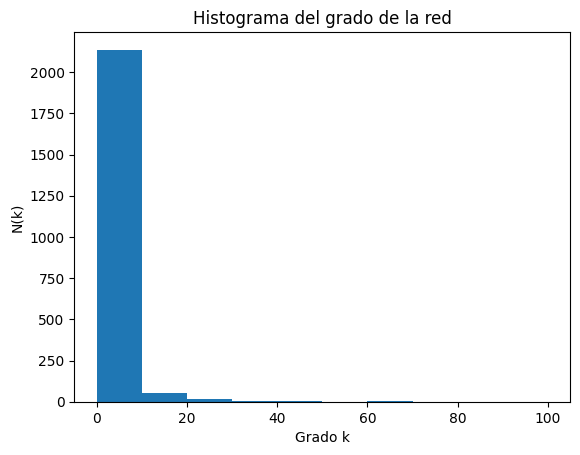

In [11]:
#Grado
grado=[]
for node in G.nodes():
    grado.append(G.degree(node))

a=plt.hist(grado)
plt.title('Histograma del grado de la red')
plt.xlabel ("Grado k")
plt.ylabel ("N(k)")
plt.show()

In [12]:
#Densidad (dirigida)
densidad = nx.number_of_edges(G) / (nx.number_of_nodes(G) * (nx.number_of_nodes(G) - 1))
densidad = round(densidad, 3)
densidad

0.001

In [13]:
#asortatividad
asortatividad =nx.degree_assortativity_coefficient(G)
asortatividad =round(asortatividad ,4)
asortatividad

0.1037

La red presenta una asortatividad positiva moderada (r = 0.1125), lo que sugiere una ligera tendencia de los inversionistas a relacionarse con actores de conectividad similar, sin evidenciar una estructura fuertemente segregada.

In [14]:
# promedio de out-degree
gradoProm_out = sum(dict(G.out_degree()).values()) / G.number_of_nodes()
print(round(gradoProm_out, 4))

1.8877


La red presenta una densidad extremadamente baja (0.0004), lo que evidencia una estructura altamente dispersa, donde las relaciones de coinversión son selectivas y se concentran en subconjuntos específicos de actores.

In [15]:
# los 20 nodos con mayor grado
from operator import itemgetter
grados = dict(G.degree())

# Ordenar
grados_ordenados = sorted(grados.items(), key=itemgetter(1), reverse=True)

# Obtener los 20 nodos
topDegree = [nodo for nodo, grado in grados_ordenados[:20]]

topDegree

['Tiger Global Management',
 'Andreessen Horowitz',
 'Sequoia Capital',
 'Y Combinator',
 'Accel',
 'Insight Partners',
 'Tencent',
 'Temasek Holdings',
 'SoftBank Vision Fund',
 'Goldman Sachs',
 'GV',
 'Sequoia Capital India',
 'Lightspeed Venture Partners',
 '500 Startups',
 'SoftBank',
 'Bessemer Venture Partners',
 'Gaingels',
 'Coatue',
 'Spark Capital',
 'General Atlantic']

Los nodos con mayor centralidad de grado corresponden a fondos de capital de riesgo globales y aceleradoras, caracterizados por una alta participación en coinversiones y una fuerte conectividad dentro del ecosistema

In [16]:
# 20 nodos con mayor PageRank
pr = nx.pagerank(G)

topPage = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:20]
topPage

[('LayerZero Labs', 0.0029876638228421657),
 ('Uber', 0.0023311433094465287),
 ('Fyllo', 0.0022016835390032334),
 ('SWVL Technologies', 0.002129520994048919),
 ('Polygon', 0.0020700281292246117),
 ('Functionland', 0.0020577929871269966),
 ('Roku', 0.002038686683931262),
 ('Sales Impact Academy', 0.0018987291302421047),
 ('Dfns', 0.001765821100168525),
 ('Blockdaemon', 0.0017457247583807344),
 ('Li Auto', 0.0017327552265470037),
 ('Solarisbank', 0.0016719092286396787),
 ('Stockal', 0.0015870853743324225),
 ('Boba Network', 0.0015746875085556435),
 ('DigiLens', 0.001540986829678156),
 ('Community Gaming', 0.0015076366269165542),
 ('2TM', 0.001494279056145036),
 ('Figment', 0.001458470972317289),
 ('ExecOnline', 0.0014527699757881133),
 ('DNAnexus', 0.001431025143820938)]

El PageRank identifica principalmente compañías receptoras de inversión que concentran capital proveniente de actores altamente centrales, destacando nodos con elevada atracción dentro del ecosistema.

## Transitividad

Se emplearon los algoritmos de Label Propagation y Fluid Communities debido a su carácter complementario en la detección de comunidades. Label Propagation permite identificar agrupamientos emergentes a partir de interacciones locales sin imponer restricciones sobre el número o tamaño de las comunidades, lo que resulta adecuado para redes construidas por similitud y para capturar dinámicas de integración y flujo de información. En contraste, Fluid Communities introduce un mecanismo de competencia entre comunidades que genera particiones más compactas y claramente delimitadas, facilitando la identificación de segmentos estructurales. El uso conjunto de ambos métodos permite evaluar la robustez de la estructura comunitaria y capturar simultáneamente procesos de integración y segmentación dentro del ecosistema empresarial.

### Label propagation

Utilizamos el algoritmo de Label Propagation para identificar comunidades emergentes a partir de las interacciones locales entre los nodos de la red. Este método asigna etiquetas que se propagan entre vecinos hasta estabilizarse, lo que permite detectar agrupamientos sin imponer previamente el número de comunidades.

Desde la perspectiva del caso, este enfoque es útil porque permite identificar agrupamientos donde las relaciones de coinversión surgen de manera orgánica. A diferencia de métodos que generan particiones más compactas, Label Propagation muestra comunidades con fronteras más difusas, lo que facilita observar dinámicas de integración y como se mueve la información entre actores. Estas comunidades pueden interpretarse como espacios de interacción donde se configuran patrones iniciales de colaboración y acceso a capital dentro del ecosistema.

##### Detección de comunidades

In [17]:
# LABEL PROPAGATION
G_undirected = G.to_undirected()
communities_lp = list(nx.algorithms.community.label_propagation_communities(G_undirected))

print(f"Número de comunidades detectadas (LP): {len(communities_lp)}")

# Diccionario nodo -> comunidad
node_community_lp = {}
for i, com in enumerate(communities_lp):
    for node in com:
        node_community_lp[node] = i

# Guardar como atributo del nodo en el grafo
nx.set_node_attributes(G, node_community_lp, "community_lp")


Número de comunidades detectadas (LP): 566


Label Propagation identificó 566 comunidades, lo que significa que la red se divide en múltiples micro-agrupamientos. Esto nos muestra que las relaciones de inversión tienden a organizarse en grupos pequeños donde los actores están más conectados entre sí que con el resto de la red.

##### Calidad de partición

In [18]:
mod_lp = modularity(G_undirected, communities_lp)
print("Modularidad (Label Propagation):", round(mod_lp, 4))


Modularidad (Label Propagation): 0.4426


La modularidad fue 0.4426, lo que indica que dentro de cada comunidad existen más conexiones entre sus propios miembros que con organizaciones externas. Esto significa que los grupos identificados no se formaron al azar, sino que reflejan patrones reales de relación dentro de la red.

#### Visualización de comunidades

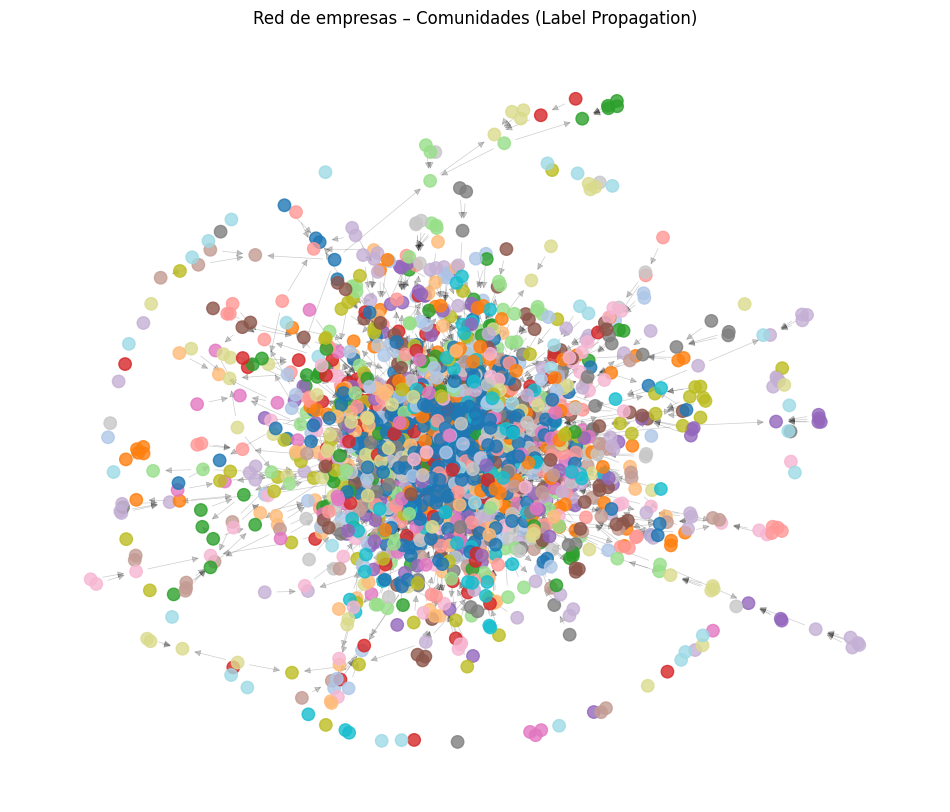

In [19]:
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)

communities_ids = [G.nodes[n].get("community_lp", -1) for n in G.nodes()]

nx.draw_networkx_nodes(
    G, pos,
    node_color=communities_ids,
    cmap=plt.cm.tab20,
    node_size=80,
    alpha=0.8
)
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)

plt.title("Red de empresas – Comunidades (Label Propagation)")
plt.axis("off")
plt.show()


La visualización muestra que la red tiene un grupo central bastante conectado y, alrededor, varios grupos más pequeños y dispersos. Se ve que no todo está concentrado en un solo bloque, sino que existen distintos agrupamientos donde algunas empresas se relacionan más entre sí.

Esto es coherente con lo que arrojó el algoritmo: muchas comunidades pequeñas y algunas más grandes, lo que sugiere que el ecosistema combina un núcleo activo con varios nichos más específicos.

##### Tamaño de comunidades

In [20]:
community_sizes_lp = pd.Series([len(c) for c in communities_lp])

print("Tamaño promedio:", round(community_sizes_lp.mean(), 2))
print("Mediana:", community_sizes_lp.median())
print("Comunidades de 1 nodo:", int((community_sizes_lp == 1).sum()))

# Distribución por rangos
bins_lp = pd.cut(community_sizes_lp, bins=[0,1,3,10,50,200], right=True)
bins_lp.value_counts().sort_index()


Tamaño promedio: 3.92
Mediana: 3.0
Comunidades de 1 nodo: 55


,count
"(0, 1]",55
"(1, 3]",335
"(3, 10]",162
"(10, 50]",11
"(50, 200]",3


El tamaño promedio de las comunidades es 3.92 nodos y la mediana es 3, lo que indica que la mayoría de los grupos son pequeños. Se observa que 335 comunidades tienen entre 2 y 3 nodos y 162 entre 4 y 10 nodos. Solo 3 comunidades superan los 50 nodos. Esto muestra que Label Propagation identifica principalmente micro-agrupamientos dentro de la red, junto con unos pocos grupos grandes más consolidados.

#### Análisis de atributos por comunidad (Label Propagation)

En esta sección analizamos las características de las empresas dentro de cada comunidad detectada por Label Propagation. El objetivo es identificar si existen patrones comunes que nos permitan entender qué tipo de organizaciones conforman cada agrupamiento.

##### Construcción del DataFrame nodo por comunidad

In [21]:
lp_comm_df = pd.DataFrame({
    "Id": list(G.nodes()),
    "community_lp": [G.nodes[n].get("community_lp") for n in G.nodes()]
})

lp_comm_df.head()


,Id,community_lp
0,Tencent,0
1,Warburg Pincus,1
2,Twitter,2
3,Ubisoft,3
4,WeWork,4


##### Unión con atributos de las empresas

In [22]:
lp_attrs = lp_comm_df.merge(nodos_clean, on="Id", how="left")
lp_attrs.head()


,Id,community_lp,Company Type,Number of Investments,Number of Lead Investments,Number of Diversity Investments,Number of Exits,Number of Lead Investors,Number of Investors,Industries,...,SEMrush - Average Visits (6 months),SEMrush - Visit Duration,Aberdeen - IT Spend,Aberdeen - IT Spend Currency,Aberdeen - IT Spend Currency (in USD),Country,Industry Group Main,Has Funding Info,Funding per Investment,Log Total Funding
0,Tencent,0,For Profit,693.0,375.0,15.0,125.0,1.0,4.0,"Advertising, Internet, Online Games, Online Po...",...,"3,553,184",600.0,NaN,NaN,NaN,China,Advertising,True,1.814830e+07,23.255117
1,Warburg Pincus,1,Unknown,433.0,286.0,22.0,131.0,NaN,NaN,"Finance, Financial Services, Venture Capital",...,"34,033.67",392.0,53801.0,USD,53801.0,United States,Financial Services,True,8.782495e+04,17.453839
2,Twitter,2,For Profit,10.0,2.0,1.0,3.0,9.0,37.0,"Blogging Platforms, Messaging, SMS, Social Media",...,"3,104,998,131.33",942.0,NaN,NaN,NaN,United States,Content and Publishing,True,4.430192e+08,22.211709
3,Ubisoft,3,For Profit,9.0,NaN,NaN,1.0,1.0,4.0,"Media and Entertainment, Publishing, Video Games",...,"27,881,933.83",392.0,NaN,NaN,NaN,France,Content and Publishing,True,8.562785e+07,20.462746
4,WeWork,4,For Profit,9.0,6.0,4.0,2.0,11.0,24.0,"Commercial Real Estate, Coworking, Property De...",...,"2,483,475.83",280.0,343977.0,USD,343977.0,United States,Real Estate,True,2.399532e+09,23.795764


Al integrar la información de comunidad con los atributos de cada empresa, obtenemos una vista consolidada que permite analizar las diferencias y similitudes entre los distintos agrupamientos detectados por el algoritmo.

##### Resumen de atributos por comunidad (Label Propagation)

##### Funciones auxiliares para análisis de categorías

In [23]:
def categoria_principal(x):
    x = x.dropna()
    if x.empty:
        return "Desconocido"
    return x.value_counts().idxmax()

def proporcion_principal(x):
    x = x.dropna()
    if x.empty:
        return 0.0
    return x.value_counts(normalize=True).iloc[0]


##### Resumen de atributos por comunidad (Label Propagation)

In [24]:
resumen_lp = (
    lp_attrs
    .groupby("community_lp")
    .agg(
        num_nodos=("Id", "size"),
        pais_principal=("Country", categoria_principal),
        porc_pais_principal=("Country", proporcion_principal),
        sector_principal=("Industry Group Main", categoria_principal),
        porc_sector_principal=("Industry Group Main", proporcion_principal),
        porc_con_funding=("Has Funding Info", "mean"),
        prom_funding_total=("Total Funding Amount Currency (in USD)", "mean"),
        prom_num_inversionistas=("Number of Investors", "mean"),
        prom_num_rondas=("Number of Funding Rounds", "mean"),
    )
    .sort_values("num_nodos", ascending=False)
)

resumen_lp.head(10)


,num_nodos,pais_principal,porc_pais_principal,sector_principal,porc_sector_principal,porc_con_funding,prom_funding_total,prom_num_inversionistas,prom_num_rondas
community_lp,,,,,,,,,
4,185,United States,0.783784,Financial Services,0.351351,0.708108,1.991823e+09,18.824427,7.776119
10,94,United States,0.648936,Financial Services,0.648936,0.765957,2.608221e+08,24.357143,5.702703
11,56,United States,0.345455,Financial Services,0.345455,0.8,1.378913e+09,16.595238,6.931818
23,50,United States,0.540000,Financial Services,0.280000,0.84,3.716938e+08,15.166667,6.558140
1,42,United States,0.439024,Financial Services,0.414634,0.853659,1.725511e+09,26.933333,10.514286
25,30,United States,0.566667,Financial Services,0.233333,0.866667,3.420851e+08,17.666667,7.296296
61,29,United States,0.931034,Financial Services,0.310345,0.689655,9.232408e+08,17.761905,5.681818
37,21,United States,0.857143,Financial Services,0.523810,0.571429,2.031961e+09,9.500000,5.133333
31,19,United States,0.578947,Financial Services,0.315789,0.789474,3.911116e+08,20.071429,5.800000


En las comunidades más grandes se ve una fuerte presencia de empresas de Estados Unidos y, en general, predomina el sector financiero. Sin embargo, no son grupos totalmente cerrados por sector, sino que mezclan distintos tipos de organizaciones.

También se observa que muchas de estas empresas ya han tenido financiación y varias rondas, lo que muestra que son comunidades donde el movimiento de capital es activo.

##### Comunidad más grande (Label Propagation)

In [25]:
# Comunidad con más nodos
com_id_lp = resumen_lp.index[0]
print("Comunidad más grande (LP):", com_id_lp)

lp_attrs[lp_attrs["community_lp"] == com_id_lp][[
    "Id",
    "Country",
    "Industry Group Main",
    "Has Funding Info",
    "Total Funding Amount Currency (in USD)",
    "Number of Investors",
    "Number of Funding Rounds",
]].head(10)

Comunidad más grande (LP): 4


,Id,Country,Industry Group Main,Has Funding Info,Total Funding Amount Currency (in USD),Number of Investors,Number of Funding Rounds
4,WeWork,United States,Real Estate,True,2.159578e+10,24.0,21.0
13,SpaceX,United States,Manufacturing,True,7.788578e+09,65.0,63.0
19,Stanza Living,India,Information Technology,True,2.276933e+08,14.0,7.0
22,Tesla,United States,Consumer Electronics,True,2.018251e+10,42.0,36.0
25,Uniphore,United States,Artificial Intelligence,True,6.208750e+08,22.0,8.0
33,Yokoy,Switzerland,Artificial Intelligence,True,1.077762e+08,10.0,3.0
45,SiFive,United States,Consumer Electronics,True,3.655000e+08,16.0,6.0
54,Zoom,United States,Hardware,True,2.760000e+08,19.0,8.0
58,Stripe,United States,Financial Services,True,2.235100e+09,48.0,19.0
61,Zendesk,United States,Other,True,8.550000e+07,11.0,8.0


Al revisar algunos casos de la comunidad más grande (ID 4), se ve que incluye empresas muy conocidas y de sectores distintos (por ejemplo WeWork, SpaceX, Tesla, Stripe, Zoom). Aunque en el resumen el sector financiero aparece como dominante, este ejemplo muestra que la comunidad también agrupa compañías de tecnología, manufactura, real estate y otros sectores.

En general, predominan empresas de Estados Unidos y casi todas tienen historial de financiación y varias rondas, lo que refuerza que es una comunidad con alta actividad de inversión.

##### Conclusiones Label Propagation

Estructura fragmentada pero consistente:
Label Propagation identificó 566 comunidades, lo que muestra que la red se organiza en múltiples micro-agrupamientos. Esto indica que las relaciones de inversión no están concentradas en un solo bloque, sino distribuidas en distintos grupos.

Estructura comunitaria real (modularidad 0.4426):
La modularidad obtenida confirma que dentro de cada comunidad existen más relaciones internas que externas. Es decir, los grupos no se forman al azar, sino que reflejan patrones reales de interacción.

Predominio geográfico y financiero:
En las comunidades más grandes se observa una fuerte presencia de empresas de Estados Unidos y una tendencia hacia el sector financiero, aunque no de forma exclusiva.

Comunidades con actividad de capital:
Las comunidades más grandes concentran empresas con historial de financiación y múltiples rondas, lo que sugiere que son espacios donde el flujo de capital es activo.

Implicación estratégica:
Dado que las comunidades 4, 10 y 11 concentran mayor número de nodos, alta proporción de empresas con historial de financiación y fuerte presencia del sector financiero en Estados Unidos, podrían considerarse comunidades más consolidadas dentro del ecosistema. Para una organización que busca financiación, puede ser más estratégico acercarse a actores vinculados a estos grupos, ya que allí se observa mayor actividad inversora y conexiones ya establecidas.

### Fluid communities

Utilizamos el algoritmo de Fluid Communities para complementar la detección de comunidades basada en interacciones locales. Este método asume que las comunidades se comportan como “fluidos” que compiten por el espacio en la red, lo que tiende a generar agrupamientos más compactos y estructuralmente cohesivos.
Desde la perspectiva del caso, este enfoque es útil porque permite identificar segmentos de actores (inversionistas y empresas) donde las relaciones de coinversión son especialmente densas. Estas comunidades fluidas pueden interpretarse como “mercados” o nichos de inversión relativamente bien delimitados, en los que resulta más probable encontrar patrones claros de colaboración y acceso a capital.

#### Calculo de comunidades

In [29]:
k = len(communities_lp)  # número de comunidades a buscar

# Convertir el grafo dirigido en no dirigido para Fluid Communities
G_undirected_fluid = G.to_undirected()

# Verificar si la red es conexa; si no, usar el componente conectado más grande
if not nx.is_connected(G_undirected_fluid):
    largest_cc = max(nx.connected_components(G_undirected_fluid), key=len)
    G_undirected_fluid_cc = G_undirected_fluid.subgraph(largest_cc).copy()
    print("La red no es conexa. Se usa el componente conectado más grande para Fluid Communities.")
else:
    G_undirected_fluid_cc = G_undirected_fluid

# Ejecutar Fluid Communities sobre el componente conectado
fluid_communities = nx.algorithms.community.asyn_fluidc(G_undirected_fluid_cc, k, seed=42)

# Convertir a lista
fluid_communities = list(fluid_communities)

print(f"Número de comunidades (Fluid Communities): {len(fluid_communities)}")

La red no es conexa. Se usa el componente conectado más grande para Fluid Communities.
Número de comunidades (Fluid Communities): 566


Se calculan las comunidades Fluid sobre el componente conectado más grande de la red y mostramos cuántas comunidades encontramos.

In [30]:
# Calcular modularidad de la partición obtenida con Fluid Communities
mod_fluid = modularity(G_undirected_fluid_cc, fluid_communities)
print(f"Modularidad (Fluid Communities): {mod_fluid:.4f}")

Modularidad (Fluid Communities): 0.3733


La modularidad de las comunidades Fluid nos permite ver qué tan separadas están. Indica que sí hay comunidades bien definidas, con más conexiones dentro de cada grupo que entre grupos, pero no es una segmentación extrema; la red sigue teniendo puentes y cierta mezcla entre comunidades.

In [31]:
# Crear diccionario nodo -> comunidad (Fluid)
node_community_fluid = {}

for i, community in enumerate(fluid_communities):
    for node in community:
        node_community_fluid[node] = i

# Guardar como atributo en el componente conectado
nx.set_node_attributes(G_undirected_fluid_cc, node_community_fluid, "community_fluid")

Guardamos el número de comunidad Fluid de cada nodo como un atributo dentro del grafo.

#### Análisis de atributos por comunidad Fluid

In [32]:
# DataFrame nodo -> comunidad (Fluid) para el componente conectado
fluid_comm_df = pd.DataFrame({
    "Id": list(G_undirected_fluid_cc.nodes()),
    "community_fluid": [
        G_undirected_fluid_cc.nodes[n]["community_fluid"]
        for n in G_undirected_fluid_cc.nodes()
    ],
})

# Unir con atributos de nodos
fluid_attrs = fluid_comm_df.merge(nodos_clean, on="Id", how="left")

# Funciones auxiliares para manejar grupos sin datos
def categoria_principal(x):
    x = x.dropna()
    if x.empty:
        return "Desconocido"
    return x.value_counts().idxmax()

def proporcion_principal(x):
    x = x.dropna()
    if x.empty:
        return 0.0
    return x.value_counts(normalize=True).iloc[0]

# Resumen de atributos clave por comunidad Fluid
resumen_fluid = (
    fluid_attrs
    .groupby("community_fluid")
    .agg(
        num_nodos=("Id", "size"),
        pais_principal=("Country", categoria_principal),
        porc_pais_principal=("Country", proporcion_principal),
        sector_principal=("Industry Group Main", categoria_principal),
        porc_sector_principal=("Industry Group Main", proporcion_principal),
        porc_con_funding=("Has Funding Info", "mean"),
        prom_funding_total=("Total Funding Amount Currency (in USD)", "mean"),
        prom_num_inversionistas=("Number of Investors", "mean"),
        prom_num_rondas=("Number of Funding Rounds", "mean"),
    )
    .sort_values("num_nodos", ascending=False)
)

resumen_fluid.head(10)

,num_nodos,pais_principal,porc_pais_principal,sector_principal,porc_sector_principal,porc_con_funding,prom_funding_total,prom_num_inversionistas,prom_num_rondas
community_fluid,,,,,,,,,
177,10,United Kingdom,0.600000,Financial Services,0.600000,0.4,9.188219e+07,9.750000,7.750000
504,9,United States,0.333333,Financial Services,0.555556,0.555556,4.546760e+08,12.000000,6.400000
322,9,United States,0.777778,Community and Lifestyle,0.444444,0.444444,1.968642e+08,6.000000,4.750000
358,9,United States,1.000000,Financial Services,0.666667,0.333333,2.669783e+08,16.666667,8.666667
117,9,United States,1.000000,Financial Services,0.555556,0.333333,1.306667e+08,8.333333,4.333333
350,8,United States,0.500000,Financial Services,0.625000,0.375,1.000544e+08,15.000000,5.666667
95,8,United States,0.625000,Financial Services,0.625000,0.375,1.046380e+08,6.666667,4.500000
356,8,United Kingdom,0.625000,Financial Services,0.625000,0.375,5.484660e+07,6.333333,3.000000
463,8,United States,0.500000,Financial Services,0.500000,0.5,3.276210e+08,7.250000,4.200000


Armamos tabla resumen por comunidad Fluid con el tamaño, el país y sector principales y promedios de variables de financiación.

In [33]:
# comunidad Fluid con más nodos
com_id = resumen_fluid.index[0]

fluid_attrs[fluid_attrs["community_fluid"] == com_id][[
    "Id",
    "Country",
    "Industry Group Main",
    "Has Funding Info",
    "Total Funding Amount Currency (in USD)",
    "Number of Investors",
    "Number of Funding Rounds",
]].head(20)

,Id,Country,Industry Group Main,Has Funding Info,Total Funding Amount Currency (in USD),Number of Investors,Number of Funding Rounds
418,Spectrum Equity,United States,Financial Services,False,NaN,NaN,NaN
453,Samos Investments,United Kingdom,Commerce and Shopping,False,NaN,NaN,NaN
601,Moneybox,United Kingdom,Financial Services,True,122558836.0,12.0,11.0
726,OTA Insight,United Kingdom,Data and Analytics,True,100000000.0,7.0,6.0
769,MoEngage,United States,Data and Analytics,True,132969926.0,13.0,10.0
1251,Oxford Capital Partners,United Kingdom,Financial Services,False,NaN,NaN,NaN
1599,Doceree,United States,Advertising,True,12000000.0,7.0,4.0
1766,F-Prime Capital,United States,Financial Services,False,NaN,NaN,NaN
1935,Eight Roads Ventures,United Kingdom,Financial Services,False,NaN,NaN,NaN
1946,Breega,United Kingdom,Financial Services,False,NaN,NaN,NaN


Miramos la comunidad con mayor número de nodos para ver sus características y saber cuales son las empresas especificas dentro de esta comunidad.

#### Visualización de la red por comunidades

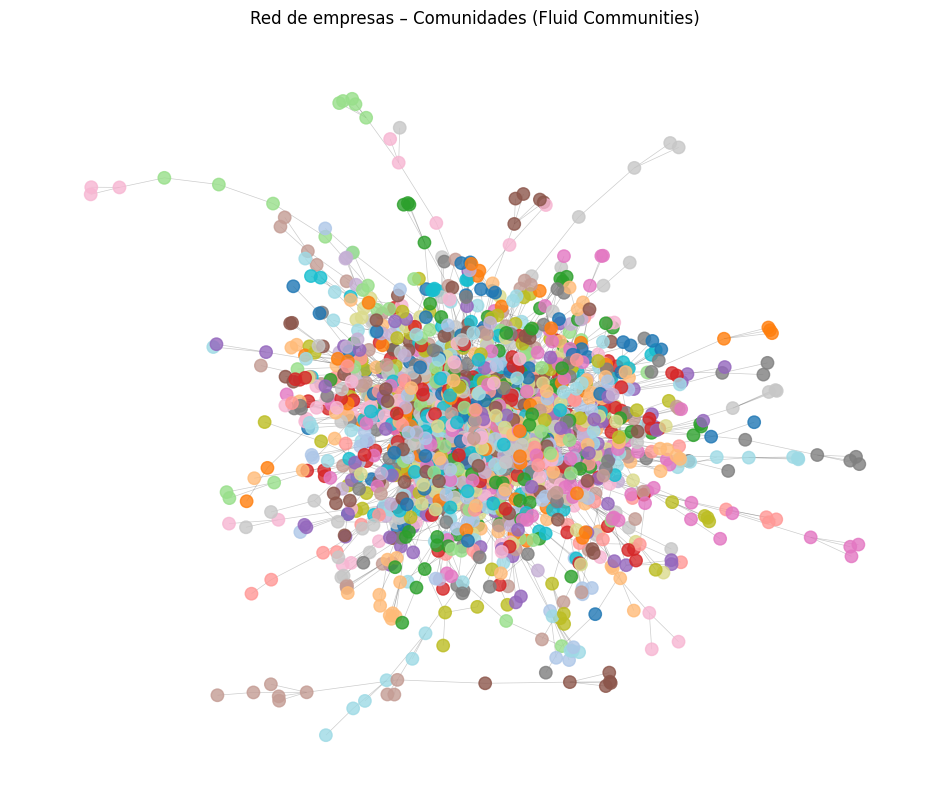

In [34]:
plt.figure(figsize=(12, 10))

# Posición de los nodos en el plano (solo componente conectado)
pos = nx.spring_layout(G_undirected_fluid_cc, seed=42)

# Colores según la comunidad Fluid de cada nodo
colors_fluid = [G_undirected_fluid_cc.nodes[n]["community_fluid"] for n in G_undirected_fluid_cc.nodes()]

nx.draw_networkx_nodes(
    G_undirected_fluid_cc,
    pos,
    node_color=colors_fluid,
    cmap=plt.cm.tab20,
    node_size=80,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_undirected_fluid_cc,
    pos,
    alpha=0.2,
    width=0.5
)

plt.title("Red de empresas – Comunidades (Fluid Communities)")
plt.axis("off")
plt.show()

In [35]:
# Comparar las comunidades de Label Propagation y Fluid Communities
nodes_for_comparison = list(G_undirected_fluid_cc.nodes())

# Comunidades según Label Propagation (tu atributo correcto)
labels_lp = [G.nodes[n]["community_lp"] for n in nodes_for_comparison]

# Comunidades según Fluid Communities
labels_fluid = [G_undirected_fluid_cc.nodes[n]["community_fluid"] for n in nodes_for_comparison]

# Cálculo del índice NMI
nmi = normalized_mutual_info_score(labels_lp, labels_fluid)
print(f"NMI entre LP y Fluid: {nmi:.3f}")


NMI entre LP y Fluid: 0.837


El valor de NMI (0.837) es alto, lo que indica que ambos algoritmos están encontrando agrupamientos bastante similares. Es decir, aunque los métodos son distintos, están detectando estructuras de comunidades parecidas dentro de la red.

Esto sugiere que la organización en comunidades no depende únicamente del algoritmo utilizado, sino que refleja una estructura consistente en las relaciones de inversión.

#### Conclusiones para Fluid Communities

Los resultados de Fluid Communities muestran un conjunto de comunidades compactas, en las que los nodos tienden a compartir país y sector económico dominante, así como patrones similares de acceso a financiación (según la tabla `resumen_fluid`). Además, las comunidades más grandes suelen presentar mayores valores promedio de monto total financiado (`prom_total_funding`), número de inversionistas (`prom_num_investors`) y número de rondas de financiación (`prom_num_rondas`), lo que indica una actividad intensa de inversión dentro de estos grupos.

Desde la perspectiva de una organización que busca ser financiada, estas comunidades pueden interpretarse como nichos de inversión relativamente bien delimitados. En particular, son especialmente atractivas aquellas comunidades Fluid que combinan: un alto número de nodos (`n_nodos`), una alta proporción de organizaciones con información de financiación (`pct_con_funding`) y valores elevados de `prom_total_funding`, `prom_num_investors` y `prom_num_rondas`. Para una organización interesada en acceder a recursos, es recomendable priorizar la creación de vínculos con estas comunidades, especialmente cuando existe alineación en sector y país, ya que concentran inversionistas activos y empresas con historial exitoso de levantamiento de capital.

La similitud entre las particiones obtenidas mediante Label Propagation y Fluid Communities, medida a través del índice de información mutua normalizada (NMI = 0.528), indica una consistencia moderada entre ambos métodos. Este resultado sugiere que, si bien los algoritmos identifican una estructura comunitaria subyacente común, difieren en la delimitación de sus fronteras, reflejando la coexistencia de integración y segmentación en la red.

 ### Método de Louvain

In [27]:
R = nx.to_undirected(G)

partition = cl.best_partition(R, random_state=10)
comLouvain = len(set(partition.values()))
print(f'Se identifican {comLouvain} comunidades')
modularidad = cl.modularity(partition, R)
print(f'Modularidad (Louvain): {modularidad:.4f}')

Se identifican 86 comunidades
Modularidad (Louvain): 0.5826


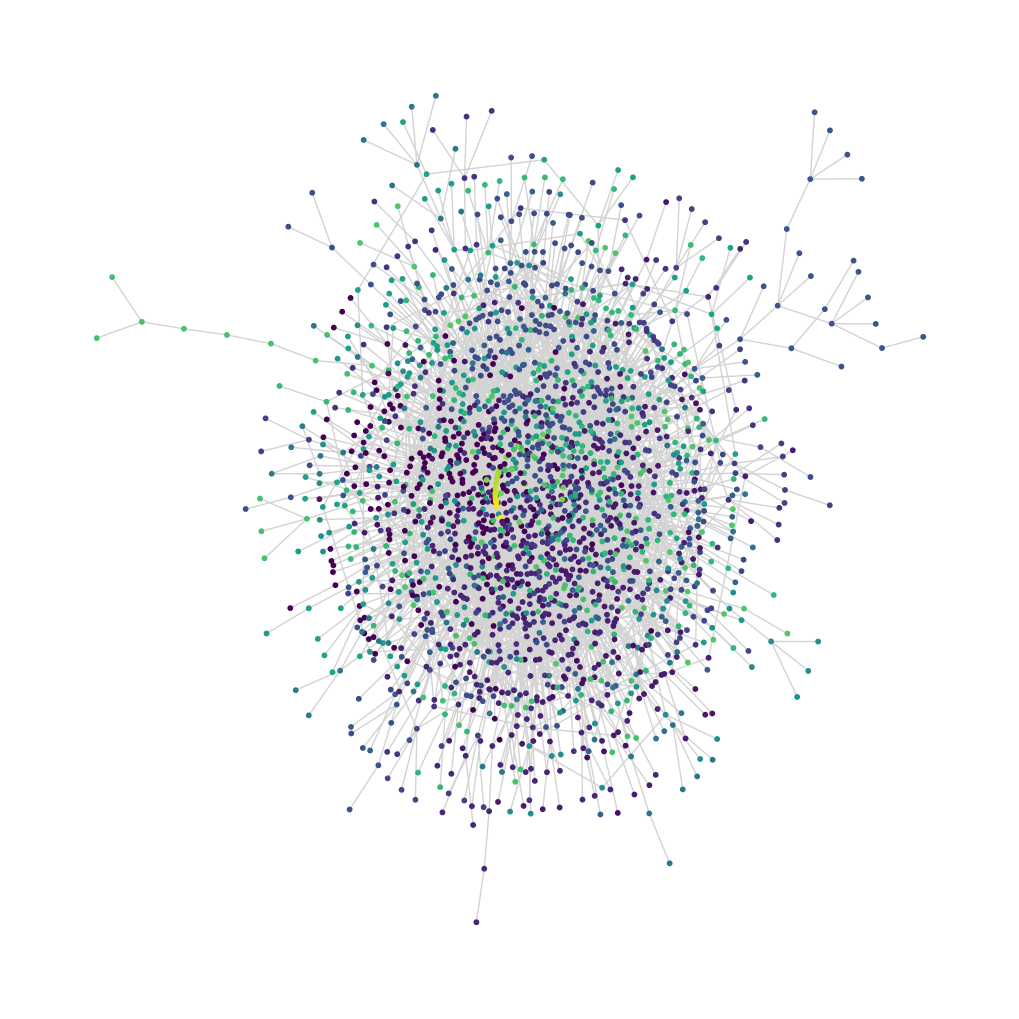

In [28]:
# Definir lienzo
fig=plt.figure(figsize=(10,10))

# Guardar posiciones
pos = nx.kamada_kawai_layout(R)

# Graficar
nx.draw(R, pos=pos, node_size=10, node_color=list(partition.values()),edge_color='lightgray')

# Mostrar gráfica
plt.show()

En este Proyecto se aplicó el algoritmo de Louvain para la detección de comunidades en la red analizada, debido a su capacidad para identificar particiones de manera eficiente en grafos de gran tamaño mediante la optimización de la modularidad. A diferencia de otros métodos evaluados, como Label Propagation y Fluid Communities, Louvain no requiere fijar previamente el número de comunidades y produce una partición emergente basada en la estructura topológica del grafo. El resultado obtenido identifica 37 comunidades con una modularidad de 0.5826, valor que indica una estructura comunitaria bien definida, caracterizada por una alta densidad de conexiones internas y una separación significativa entre comunidades. Esta combinación de estabilidad, escalabilidad y una métrica objetiva como la modularidad justifica la elección de Louvain como uno de los métodos más adecuados para el análisis de comunidades en esta red.

In [37]:
# DataFrame nodo -> comunidad (LOUVAIN)
louvain_df = pd.DataFrame({
    "Id": list(partition.keys()),
    "community_louvain": list(partition.values())
})

louvain_attrs = louvain_df.merge(nodos_clean, on="Id", how="left")

def categoria_principal(x):
    x = x.dropna()
    if x.empty:
        return "Desconocido"
    return x.value_counts().idxmax()

def proporcion_principal(x):
    x = x.dropna()
    if x.empty:
        return 0.0
    return x.value_counts(normalize=True).iloc[0]
resumen_louvain = (
    louvain_attrs
    .groupby("community_louvain")
    .agg(
        num_nodos=("Id", "size"),
        pais_principal=("Country", categoria_principal),
        porc_pais_principal=("Country", proporcion_principal),
        sector_principal=("Industry Group Main", categoria_principal),
        porc_sector_principal=("Industry Group Main", proporcion_principal),
        porc_con_funding=("Has Funding Info", "mean"),
        prom_funding_total=("Total Funding Amount Currency (in USD)", "mean"),
        prom_num_inversionistas=("Number of Investors", "mean"),
        prom_num_rondas=("Number of Funding Rounds", "mean"),
    )
    .sort_values("num_nodos", ascending=False)
)

resumen_louvain


,num_nodos,pais_principal,porc_pais_principal,sector_principal,porc_sector_principal,porc_con_funding,prom_funding_total,prom_num_inversionistas,prom_num_rondas
community_louvain,,,,,,,,,
0,228,United States,0.427313,Financial Services,0.387665,0.674009,2.569337e+09,16.858108,7.713376
9,185,United States,0.616216,Financial Services,0.621622,0.643243,3.000300e+08,23.637931,6.008130
5,184,United States,0.706522,Financial Services,0.451087,0.63587,4.171911e+08,16.474138,5.886179
20,126,India,0.396825,Financial Services,0.531746,0.531746,3.012764e+08,12.388060,6.250000
56,123,United States,0.770492,Financial Services,0.426230,0.516393,4.297939e+08,14.123077,5.432836
...,...,...,...,...,...,...,...,...,...
81,1,United States,1.000000,Transportation,1.000000,1.0,1.350000e+05,NaN,2.000000
82,1,India,1.000000,Education,1.000000,1.0,1.060000e+06,6.000000,3.000000
83,1,United States,1.000000,Financial Services,1.000000,0.0,NaN,NaN,NaN


El algoritmo de Louvain identifica una estructura modular altamente fragmentada (86 comunidades), caracterizada por la presencia de algunos bloques de gran tamaño y una periferia compuesta por múltiples comunidades unitarias. Las comunidades más numerosas muestran una clara dominancia del sector Financial Services, con proporciones internas que oscilan entre aproximadamente 38% y 62%, lo que sugiere una fuerte homofilia sectorial como principio organizador de la red. Asimismo, se observa segmentación geográfica significativa, particularmente con predominancia de nodos de Estados Unidos y, en menor medida, India, indicando que la modularidad capturada no es únicamente sectorial sino también territorial. Las diferencias en los promedios de financiamiento, número de inversionistas y rondas sugieren la existencia de sub-ecosistemas financieros con dinámicas de capital diferenciadas dentro del mismo sector. En conjunto, los resultados evidencian una red estructurada en clústeres sectorial-geográficos bien definidos, acompañados de una periferia poco integrada, consistente con patrones de homofilia y concentración de capital en ecosistemas empresariales.

In [38]:
# Identificar la comunidad Fluid con mayor número de nodos
com_id = resumen_fluid["num_nodos"].idxmax()

# Filtrar nodos pertenecientes a esa comunidad
top_fluid_com = (
    fluid_attrs
    .loc[fluid_attrs["community_fluid"] == com_id, [
        "Id",
        "Country",
        "Industry Group Main",
        "Has Funding Info",
        "Total Funding Amount Currency (in USD)",
        "Number of Investors",
        "Number of Funding Rounds",
    ]]
    .sort_values(
        by="Total Funding Amount Currency (in USD)",
        ascending=False
    )
)

top_fluid_com.head(20)


,Id,Country,Industry Group Main,Has Funding Info,Total Funding Amount Currency (in USD),Number of Investors,Number of Funding Rounds
769,MoEngage,United States,Data and Analytics,True,132969926.0,13.0,10.0
601,Moneybox,United Kingdom,Financial Services,True,122558836.0,12.0,11.0
726,OTA Insight,United Kingdom,Data and Analytics,True,100000000.0,7.0,6.0
1599,Doceree,United States,Advertising,True,12000000.0,7.0,4.0
418,Spectrum Equity,United States,Financial Services,False,NaN,NaN,NaN
453,Samos Investments,United Kingdom,Commerce and Shopping,False,NaN,NaN,NaN
1251,Oxford Capital Partners,United Kingdom,Financial Services,False,NaN,NaN,NaN
1766,F-Prime Capital,United States,Financial Services,False,NaN,NaN,NaN
1935,Eight Roads Ventures,United Kingdom,Financial Services,False,NaN,NaN,NaN
1946,Breega,United Kingdom,Financial Services,False,NaN,NaN,NaN


### Conclusión sobre la comunidad más grande

La comunidad más numerosa identificada presenta una heterogeneidad sectorial moderada, aunque con una clara predominancia del sector *Financial Services*, acompañada por empresas de *Data and Analytics*. Los nodos con información de financiamiento muestran montos elevados (entre aproximadamente 100 y 133 millones USD), así como un número relevante de inversionistas (7–13) y rondas de financiamiento (4–11), lo que evidencia la presencia de actores con alta actividad de capital dentro del clúster. No obstante, también se observan múltiples nodos sin información de financiamiento, particularmente fondos y firmas de inversión, lo que sugiere que la comunidad no está compuesta exclusivamente por startups, sino por un ecosistema mixto que integra empresas operativas y actores financieros.

Desde una perspectiva estructural, la cohesión de esta comunidad parece estar determinada por patrones relacionales —como coinversión o vínculos institucionales— más que por la magnitud absoluta del financiamiento. La coexistencia de empresas tecnológicas y fondos de capital indica una topología donde los intermediarios financieros actúan como nodos articuladores dentro del clúster.

---

### Conclusión general sobre el algoritmo de Louvain

El algoritmo de Louvain revela una estructura modular bien definida, caracterizada por bloques densos y una segmentación sectorial dominante, especialmente en torno al ecosistema financiero. La presencia de comunidades grandes junto con múltiples comunidades pequeñas o unitarias sugiere una red con núcleo cohesionado y periferia fragmentada. En este contexto, Louvain captura la arquitectura meso-estructural de la red, identificando sub-ecosistemas económicos interconectados cuya cohesión responde principalmente a la conectividad estructural y a la homofilia sectorial, más que a la similitud estricta de atributos financieros.
